# Week 9 — Future Work 2 (FW2): Decoder-level Embedding Injection

**Dissertation:** Advance Multimodel Generative Artificial Intelligence — Controllable Image Captioning with Large Vision-Language Models
**Author:** Avinash Sahu  |  **Supervisor:** Varun Ojha

**Goal (interim report, FW2):** replace the Week 5/6 *retrieval-based* embedding steering with
**true decoder-level embedding injection** — i.e. add a steering vector directly into LLaVA's
decoder hidden states during generation, so the model genuinely *generates* a steered caption
rather than returning the caption of a nearest-neighbour image (which produced the degenerate
BLEU-4 = 1.0000 artefact in Week 6).

**Method (contrastive activation addition):**
1. Using COCO instance labels, split the **train** images into those that contain the target
   category (`person`) and those that do not.
2. Run both groups through LLaVA and capture the mean hidden state at a chosen decoder layer.
3. The steering direction is `mean(with) − mean(without)` in LLaVA's own 4096-d hidden space.
4. During generation, a forward hook adds `alpha × direction` to that layer's output, steering
   the caption toward the concept.

Everything stays on your existing **1,000-image** set (`data/processed/`, 100-image test split)
and reuses your Week 1–8 conventions (paths, model, `generate_caption()`, BLEU/CLIP, seed 42).


In [2]:
# ── CELL 1 — Mount Google Drive ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')


Mounted at /content/drive
Drive mounted.


In [3]:
# ── CELL 2 — Install packages ─────────────────────────────────────────────
!pip install -q --upgrade accelerate
!pip install -q sentencepiece nltk pycocotools
import nltk
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
import transformers
print(f'transformers : {transformers.__version__}')
print('Packages ready. No restart needed.')


transformers : 5.12.1
Packages ready. No restart needed.


In [4]:
# ── CELL 3 — Paths and config ─────────────────────────────────────────────
import os
BASE          = '/content/drive/MyDrive/dissertation_final'
COCO_IMG_DIR  = f'{BASE}/data/coco/val2017'
INSTANCES_FILE= f'{BASE}/data/coco/annotations/instances_val2017.json'
PROCESSED_DIR = f'{BASE}/data/processed'        # SAME 1,000-image splits as Week 1
RESULTS_DIR   = f'{BASE}/results'
MODEL_CACHE   = f'{BASE}/models/llava_cache'

# FW2 config
TARGET_CAT    = 'person'        # same target category as Week 6
TARGET_WORDS  = ['person', 'people', 'man', 'woman', 'men', 'women', 'child', 'boy', 'girl']
STEER_LAYER   = None            # None -> auto (middle decoder layer)
STRENGTHS     = [1, 2, 4]       # alpha coefficients on the contrast direction (tunable)
N_DIR         = 40              # train images per group (with / without) for the direction
RANDOM_SEED   = 42

os.makedirs(RESULTS_DIR, exist_ok=True)
print('Required files:')
for f in [f'{PROCESSED_DIR}/train.csv', f'{PROCESSED_DIR}/test.csv', INSTANCES_FILE]:
    print(f'  {"OK" if os.path.exists(f) else "MISSING"} : {os.path.basename(f)}')
print('\nIf instances_val2017.json is missing, it ships inside the annotations zip you')
print('downloaded in Week 1 (annotations_trainval2017.zip) — re-run Week 1 Cell 3 if needed.')


Required files:
  OK : train.csv
  OK : test.csv
  OK : instances_val2017.json

If instances_val2017.json is missing, it ships inside the annotations zip you
downloaded in Week 1 (annotations_trainval2017.zip) — re-run Week 1 Cell 3 if needed.


In [5]:
# ── CELL 4 — GPU check ────────────────────────────────────────────────────
import torch
if torch.cuda.is_available():
    print('GPU :', torch.cuda.get_device_name(0),
          f'| VRAM {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB',
          f'| CUDA {torch.version.cuda} | torch {torch.__version__}')
else:
    print('No GPU. Runtime -> Change runtime type -> A100/T4 GPU.')


GPU : NVIDIA A100-SXM4-80GB | VRAM 85.1 GB | CUDA 12.8 | torch 2.11.0+cu128


In [6]:
# ── CELL 5 — Imports ──────────────────────────────────────────────────────
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm import tqdm
from contextlib import contextmanager
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from transformers import LlavaNextForConditionalGeneration, CLIPProcessor, CLIPModel
import transformers
if tuple(int(x) for x in transformers.__version__.split('.')[:2]) >= (4, 38):
    from transformers import AutoProcessor as LlavaProcessor
else:
    from transformers import LlavaNextProcessor as LlavaProcessor
print('Imports done.')


Imports done.


In [7]:
# ── CELL 6 — Load LLaVA (same loader as Week 3) ──────────────────────────
def load_llava():
    load_from = MODEL_CACHE if os.path.exists(f'{MODEL_CACHE}/config.json') else 'llava-hf/llava-v1.6-mistral-7b-hf'
    print(f'Loading from: {load_from}')
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    processor = LlavaProcessor.from_pretrained(load_from, use_fast=False)
    model     = LlavaNextForConditionalGeneration.from_pretrained(
        load_from, torch_dtype=torch.float16, device_map='auto', low_cpu_mem_usage=True)
    model.eval()
    print(f'Loaded on {next(model.parameters()).device} | dtype: {next(model.parameters()).dtype}')
    return processor, model

processor, model = load_llava()
print('LLaVA ready.')


Loading from: /content/drive/MyDrive/dissertation_final/models/llava_cache


[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

Loaded on cuda:0 | dtype: torch.float16
LLaVA ready.


In [8]:
# ── CELL 7 — generate_caption + BLEU/CLIP metrics (identical to Week 3) ───
def generate_caption(processor, model, image, prompt='Describe this image in detail.', max_new_tokens=100):
    conv   = [{'role':'user','content':[{'type':'image'},{'type':'text','text':prompt}]}]
    text   = processor.apply_chat_template(conv, add_generation_prompt=True)
    inputs = processor(images=image, text=text, return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, temperature=None, top_p=None)
    return processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0].strip()

_clip_proc, _clip_model = None, None
def get_clip():
    global _clip_proc, _clip_model
    if _clip_model is None:
        _clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
        _clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(
            'cuda' if torch.cuda.is_available() else 'cpu').eval()
    return _clip_proc, _clip_model

def compute_sentence_bleu(gen, refs):
    s = SmoothingFunction().method1
    return round(sentence_bleu([r.lower().split() for r in refs], gen.lower().split(), smoothing_function=s), 4)

def compute_bleu(generated, references):
    s = SmoothingFunction().method1
    hyps = [g.lower().split() for g in generated]
    refs = [[r.lower().split() for r in rs] for rs in references]
    return {'bleu_1': round(corpus_bleu(refs, hyps, weights=(1,0,0,0), smoothing_function=s), 4),
            'bleu_4': round(corpus_bleu(refs, hyps, weights=(.25,.25,.25,.25), smoothing_function=s), 4)}

def compute_clip_scores_batch(images, captions, batch_size=16):
    proc, mdl = get_clip(); dev, scores = next(mdl.parameters()).device, []
    for i in range(0, len(images), batch_size):
        inp = proc(text=captions[i:i+batch_size], images=images[i:i+batch_size],
                   return_tensors='pt', padding=True, truncation=True, max_length=77)
        inp = {k: v.to(dev) for k, v in inp.items()}
        with torch.no_grad():
            out = mdl(**inp)
            ie = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
            te = out.text_embeds  / out.text_embeds.norm(dim=-1,  keepdim=True)
            scores.extend((ie*te).sum(dim=-1).tolist())
    return [round(s, 4) for s in scores]

print('generate_caption + metrics ready.')


generate_caption + metrics ready.


In [9]:
# ── CELL 8 — Split TRAIN images into WITH / WITHOUT the target category ──
# Uses COCO instance annotations to label which images actually contain `person`.
with open(INSTANCES_FILE) as f:
    inst = json.load(f)

catid_to_name = {c['id']: c['name'] for c in inst['categories']}
img_to_cats = {}
for a in inst['annotations']:
    img_to_cats.setdefault(a['image_id'], set()).add(catid_to_name[a['category_id']])

train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')
with_ids, without_ids = [], []
for _, r in train_df.iterrows():
    cats = img_to_cats.get(int(r['image_id']), set())
    (with_ids if TARGET_CAT in cats else without_ids).append(r['img_path'])

rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(with_ids); rng.shuffle(without_ids)
with_paths    = with_ids[:N_DIR]
without_paths = without_ids[:N_DIR]
print(f"Target category: '{TARGET_CAT}'")
print(f'  train images WITH    {TARGET_CAT}: {len(with_ids)}  (using {len(with_paths)})')
print(f'  train images WITHOUT {TARGET_CAT}: {len(without_ids)}  (using {len(without_paths)})')


Target category: 'person'
  train images WITH    person: 439  (using 40)
  train images WITHOUT person: 361  (using 40)


In [10]:
# ── CELL 9 — Locate decoder layers and build the steering direction ──────
def get_decoder_layers(model):
    for path in ['language_model.model.layers', 'model.language_model.layers',
                 'language_model.layers', 'model.language_model.model.layers']:
        obj = model; ok = True
        for p in path.split('.'):
            if hasattr(obj, p): obj = getattr(obj, p)
            else: ok = False; break
        if ok and isinstance(obj, torch.nn.ModuleList):
            print(f'Decoder layers found at: model.{path}  (n={len(obj)})')
            return obj
    for name, mod in model.named_modules():
        if isinstance(mod, torch.nn.ModuleList) and len(mod) >= 20 and name.endswith('layers'):
            print(f'Decoder layers found at: {name}  (n={len(mod)})')
            return mod
    raise RuntimeError('Could not locate decoder layers.')

layers = get_decoder_layers(model)
LAYER  = STEER_LAYER if STEER_LAYER is not None else len(layers)//2
print(f'Steering at decoder layer index: {LAYER}')

def mean_hidden_for_image(img_path, prompt='Describe this image in detail.'):
    """Capture the mean layer-LAYER hidden state for one image (forward pass only)."""
    store = {}
    def cap_hook(m, i, o):
        hs = o[0] if isinstance(o, tuple) else o
        store['h'] = hs.detach().float().mean(dim=1).squeeze(0).cpu()   # (hidden,)
    h = layers[LAYER].register_forward_hook(cap_hook)
    try:
        image = Image.open(img_path).convert('RGB')
        conv  = [{'role':'user','content':[{'type':'image'},{'type':'text','text':prompt}]}]
        text  = processor.apply_chat_template(conv, add_generation_prompt=True)
        inp   = processor(images=image, text=text, return_tensors='pt').to(model.device)
        with torch.no_grad():
            model(**inp)
    finally:
        h.remove()
    return store['h']

print('Capturing hidden states for WITH group...')
with_vecs    = torch.stack([mean_hidden_for_image(p) for p in tqdm(with_paths)])
print('Capturing hidden states for WITHOUT group...')
without_vecs = torch.stack([mean_hidden_for_image(p) for p in tqdm(without_paths)])

direction = (with_vecs.mean(0) - without_vecs.mean(0))   # contrast direction in hidden space
direction = direction.to(model.device)
print(f'Steering direction built. shape={tuple(direction.shape)} | L2 norm={direction.norm():.3f}')


Decoder layers found at: model.model.language_model.layers  (n=32)
Steering at decoder layer index: 16
Capturing hidden states for WITH group...


100%|██████████| 40/40 [00:39<00:00,  1.01it/s]


Capturing hidden states for WITHOUT group...


100%|██████████| 40/40 [00:39<00:00,  1.01it/s]

Steering direction built. shape=(4096,) | L2 norm=0.564


In [11]:
# ── CELL 10 — Steering hook (adds alpha*direction into the decoder) ──────
@contextmanager
def steering(alpha):
    if alpha == 0:
        yield; return
    add = (alpha * direction).to(next(model.parameters()).dtype)
    def steer_hook(m, i, o):
        if isinstance(o, tuple):
            return (o[0] + add,) + o[1:]
        return o + add
    handle = layers[LAYER].register_forward_hook(steer_hook)
    try:
        yield
    finally:
        handle.remove()

def generate_steered(image, alpha, prompt='Describe this image in detail.', max_new_tokens=100):
    with steering(alpha):
        return generate_caption(processor, model, image, prompt=prompt, max_new_tokens=max_new_tokens)

# quick smoke test on one test image
_test_df = pd.read_csv(f'{PROCESSED_DIR}/test.csv')
_img = Image.open(_test_df.iloc[0]['img_path']).convert('RGB')
print('alpha=0 :', generate_steered(_img, 0)[:120])
print('alpha=4 :', generate_steered(_img, 4)[:120])


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


alpha=0 : In the heart of a gravel field, a lively game of soccer unfolds. Two players, clad in vibrant red and black jerseys, are
alpha=4 : In the heart of the image, a lively game of frisbee unfolds on a sandy beach. The main focus is on two players, both dre


In [12]:
# ── CELL 11 — Run injection at each strength on the 100-image test set ───
import re
test_df = pd.read_csv(f'{PROCESSED_DIR}/test.csv')

def mentions_target(text):
    toks = set(re.findall(r"[a-z']+", text.lower()))
    return int(any(w in toks for w in TARGET_WORDS))

for alpha in STRENGTHS:
    out_csv = f'{RESULTS_DIR}/week9_fw2_inject_a{alpha}.csv'
    if os.path.exists(out_csv):
        print(f'[skip] alpha={alpha} done -> {os.path.basename(out_csv)}'); continue
    print(f'\n=== decoder injection | alpha={alpha} ===')
    records, gens, imgs = [], [], []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=f'a={alpha}'):
        image = Image.open(row['img_path']).convert('RGB')
        gen   = generate_steered(image, alpha)
        refs  = row['captions'].split(' | ')
        records.append({'image_id': row['image_id'], 'img_path': row['img_path'],
                        'generated': gen, 'references': row['captions'],
                        'bleu4': compute_sentence_bleu(gen, refs),
                        'mentions_target': mentions_target(gen)})
        gens.append(gen); imgs.append(image)
    for r, c in zip(records, compute_clip_scores_batch(imgs, gens)):
        r['clip_score'] = c
    pd.DataFrame(records).to_csv(out_csv, index=False)
    print(f'  saved -> {out_csv}')
print('\nAll strengths complete.')


[skip] alpha=1 done -> week9_fw2_inject_a1.csv
[skip] alpha=2 done -> week9_fw2_inject_a2.csv
[skip] alpha=4 done -> week9_fw2_inject_a4.csv

All strengths complete.


In [13]:
# ── CELL 12 — Aggregate FW2 results + compare to baseline & Week 6 ───────
rows = []

# Baseline reference (reuse Week 3 zero-shot, with its own target-mention rate)
base_csv = f'{RESULTS_DIR}/week3_baseline.csv'
if os.path.exists(base_csv):
    import re
    bdf = pd.read_csv(base_csv)
    gcol = 'generated' if 'generated' in bdf.columns else bdf.columns[2]
    base_mention = float(bdf[gcol].astype(str).apply(
        lambda t: int(any(w in set(re.findall(r"[a-z']+", t.lower())) for w in TARGET_WORDS))).mean())
    bleu = compute_bleu(bdf[gcol].tolist(), [str(r).split(' | ') for r in bdf['references']])            if 'references' in bdf.columns else {'bleu_1':None,'bleu_4':None}
    rows.append({'Technique':'baseline (no injection)', 'alpha':0,
                 'BLEU-1':bleu['bleu_1'], 'BLEU-4':bleu['bleu_4'],
                 'CLIP score (mean)': round(bdf['clip_score'].mean(),4) if 'clip_score' in bdf.columns else None,
                 'target mention rate': round(base_mention,3), 'N':len(bdf)})

for alpha in STRENGTHS:
    p = f'{RESULTS_DIR}/week9_fw2_inject_a{alpha}.csv'
    if not os.path.exists(p): continue
    df = pd.read_csv(p)
    bleu = compute_bleu(df['generated'].tolist(), [str(r).split(' | ') for r in df['references']])
    rows.append({'Technique':f'decoder injection (alpha={alpha})', 'alpha':alpha,
                 'BLEU-1':bleu['bleu_1'], 'BLEU-4':bleu['bleu_4'],
                 'CLIP score (mean)': round(df['clip_score'].mean(),4),
                 'target mention rate': round(df['mentions_target'].mean(),3), 'N':len(df)})

fw2 = pd.DataFrame(rows)
fw2.to_csv(f'{RESULTS_DIR}/FINAL_results_fw2.csv', index=False)
print('Saved: FINAL_results_fw2.csv\n')
print('='*84)
print(f"FW2 — decoder-level embedding injection  (target = '{TARGET_CAT}', layer {LAYER}, test n=100)")
print('='*84)
print(fw2.to_string(index=False))

# Contrast with the Week 6 retrieval-based steering, if present
for name in ['week6_embedding_results.csv','week6_embedding_eval.csv']:
    wp = f'{RESULTS_DIR}/{name}'
    if os.path.exists(wp):
        w6 = pd.read_csv(wp)
        if 'clip_score' in w6.columns:
            print(f"\nWeek 6 retrieval-based steering CLIP (mean): {round(w6['clip_score'].mean(),4)} "
                  f"(BLEU-4 there was a retrieval artefact). FW2 captions are genuinely generated.")
        break


Saved: FINAL_results_fw2.csv

FW2 — decoder-level embedding injection  (target = 'person', layer 16, test n=100)
                  Technique  alpha  BLEU-1  BLEU-4  CLIP score (mean)  target mention rate   N
    baseline (no injection)      0  0.1669  0.0213             0.3173                 0.33 100
decoder injection (alpha=1)      1  0.1680  0.0211             0.3165                 0.35 100
decoder injection (alpha=2)      2  0.1677  0.0208             0.3134                 0.38 100
decoder injection (alpha=4)      4  0.1623  0.0206             0.3084                 0.42 100

Week 6 retrieval-based steering CLIP (mean): 0.2969 (BLEU-4 there was a retrieval artefact). FW2 captions are genuinely generated.


[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


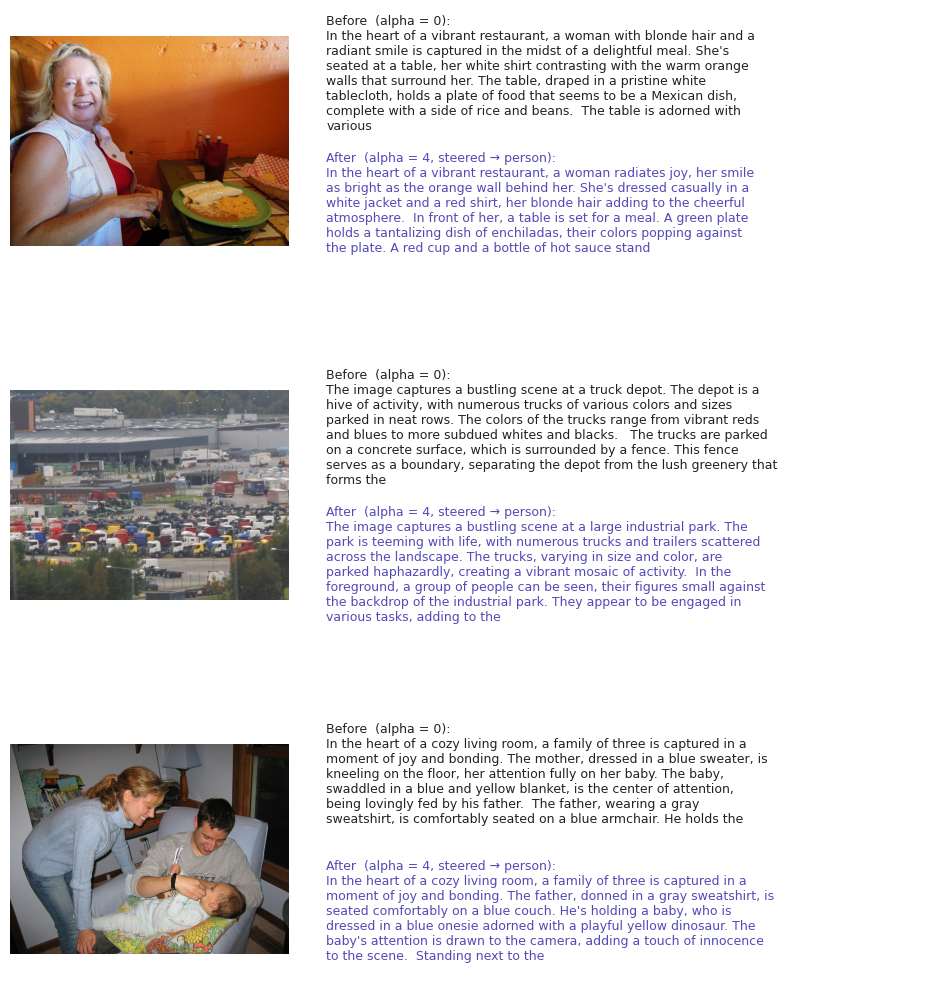

Saved figure: /content/drive/MyDrive/dissertation_final/results/week9_fw2_qualitative_examples.png


In [14]:
# -- CELL 12b -- Qualitative before/after (no overlap): one row per caption --
import re, textwrap
def _mentions(t):
    toks = set(re.findall(r"[a-z']+", str(t).lower()))
    return any(w in toks for w in TARGET_WORDS)

alpha_hi = max(STRENGTHS)
examples, seen = [], test_df.sample(min(24, len(test_df)), random_state=RANDOM_SEED)
for _, row in seen.iterrows():
    img = Image.open(row['img_path']).convert('RGB')
    c0  = generate_steered(img, 0)
    c1  = generate_steered(img, alpha_hi)
    if (_mentions(c1) and not _mentions(c0)) or (c1.strip() != c0.strip()):
        examples.append((img, c0, c1))
    if len(examples) >= 3:
        break
if len(examples) < 3:
    for _, row in seen.iterrows():
        if len(examples) >= 3: break
        img = Image.open(row['img_path']).convert('RGB')
        examples.append((img, generate_steered(img, 0), generate_steered(img, alpha_hi)))

WRAP = 70                     # characters per line before wrapping
n = len(examples)
fig, axes = plt.subplots(n, 1, figsize=(12, 4.2 * n))
if n == 1:
    axes = [axes]

for ax, (img, c0, c1) in zip(axes, examples):
    ax.axis('off')
    # image on the left
    axim = ax.inset_axes([0.0, 0.0, 0.30, 1.0])
    axim.imshow(img); axim.axis('off')
    # captions on the right, each wrapped and given its own block
    before_txt = "Before  (alpha = 0):\n" + textwrap.fill(c0, WRAP)
    after_txt  = f"After  (alpha = {alpha_hi}, steered \u2192 {TARGET_CAT}):\n" + textwrap.fill(c1, WRAP)
    ax.text(0.34, 0.98, before_txt, fontsize=9, va='top', ha='left',
            transform=ax.transAxes, color='#222222')
    ax.text(0.34, 0.46, after_txt, fontsize=9, va='top', ha='left',
            transform=ax.transAxes, color='#534AB7')

plt.subplots_adjust(hspace=0.35)
out = f'{RESULTS_DIR}/week9_fw2_qualitative_examples.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure:', out)

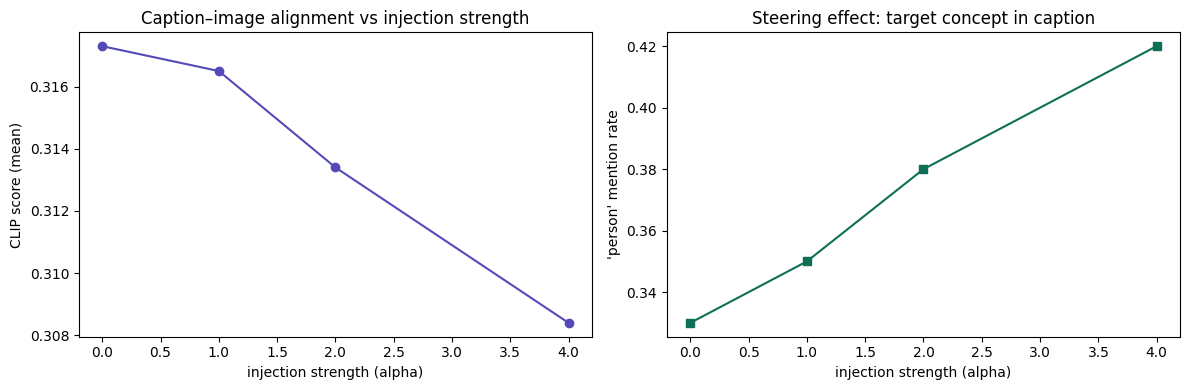

Saved figure: /content/drive/MyDrive/dissertation_final/results/week9_fw2_injection_curves.png

FW2 complete. Next future-work item: FW4 (BLIP-2 comparison) or FW5 (hallucination rate).


In [15]:
# ── CELL 13 — Plot: strength vs CLIP and vs target-mention rate ──────────
plot_df = fw2[fw2['alpha'] >= 0].copy()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(plot_df['alpha'], plot_df['CLIP score (mean)'], 'o-', color='#534AB7')
ax[0].set_xlabel('injection strength (alpha)'); ax[0].set_ylabel('CLIP score (mean)')
ax[0].set_title('Caption–image alignment vs injection strength')
ax[1].plot(plot_df['alpha'], plot_df['target mention rate'], 's-', color='#0F6E56')
ax[1].set_xlabel('injection strength (alpha)'); ax[1].set_ylabel(f"'{TARGET_CAT}' mention rate")
ax[1].set_title('Steering effect: target concept in caption')
plt.tight_layout()
out = f'{RESULTS_DIR}/week9_fw2_injection_curves.png'
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print('Saved figure:', out)
print('\nFW2 complete. Next future-work item: FW4 (BLIP-2 comparison) or FW5 (hallucination rate).')
